# Process Single Table

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration to display graphs in the notebook
%matplotlib inline
plt.style.use('ggplot')
sns.set(style='whitegrid')


# Data Loading and Initial Exploration


In [2]:
# Load the dataset
df = pd.read_csv('Datasets/Tabular/Time_series/csv/dataset_time_series.csv')

# Display basic information
print("Table shape:", df.shape)
print("Column names:", df.columns.tolist())
df.head()


Table shape: (9990, 13)
Column names: ['Unnamed: 0', 'ID', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_7', 'Feature_8', 'Feature_9', 'Feature_10', 'Target']


,Unnamed: 0,ID,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Target
0,10,11,-0.221708,1.133047,1.352241,-0.124647,4.017140,1.836551,-0.478149,2.074969,2.129173,-0.232051,2.304265
1,11,12,-0.221864,1.196557,1.308560,-0.850371,4.322888,2.102496,-0.969116,-2.437057,1.455233,0.441201,0.452407
2,12,13,0.132982,0.630783,0.991719,-0.564366,3.008537,2.650296,0.899033,-4.669752,1.825879,-0.501489,2.858446
3,13,14,-0.943639,0.969822,0.903074,-0.188469,2.034749,2.821024,0.170669,-4.823012,1.980669,-0.103675,2.468120
4,14,15,-0.848458,1.440260,1.624604,-1.532611,0.911643,2.157261,-0.214645,-0.074111,2.073125,0.239503,2.280645


# Categorical Data Encoding


In [3]:
# Transform categorical columns to numerical
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for col in df.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
print("\nDataFrame after categorical encoding:")
df.head()



DataFrame after categorical encoding:


,Unnamed: 0,ID,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Target
0,10,11,-0.221708,1.133047,1.352241,-0.124647,4.017140,1.836551,-0.478149,2.074969,2.129173,-0.232051,2.304265
1,11,12,-0.221864,1.196557,1.308560,-0.850371,4.322888,2.102496,-0.969116,-2.437057,1.455233,0.441201,0.452407
2,12,13,0.132982,0.630783,0.991719,-0.564366,3.008537,2.650296,0.899033,-4.669752,1.825879,-0.501489,2.858446
3,13,14,-0.943639,0.969822,0.903074,-0.188469,2.034749,2.821024,0.170669,-4.823012,1.980669,-0.103675,2.468120
4,14,15,-0.848458,1.440260,1.624604,-1.532611,0.911643,2.157261,-0.214645,-0.074111,2.073125,0.239503,2.280645


# Correlation Analysis
### We are using the absolute value of the correlation matrix to get insight on the magnitude of the correlation between the features, as the sign of the correlation is not important for the feature selection step


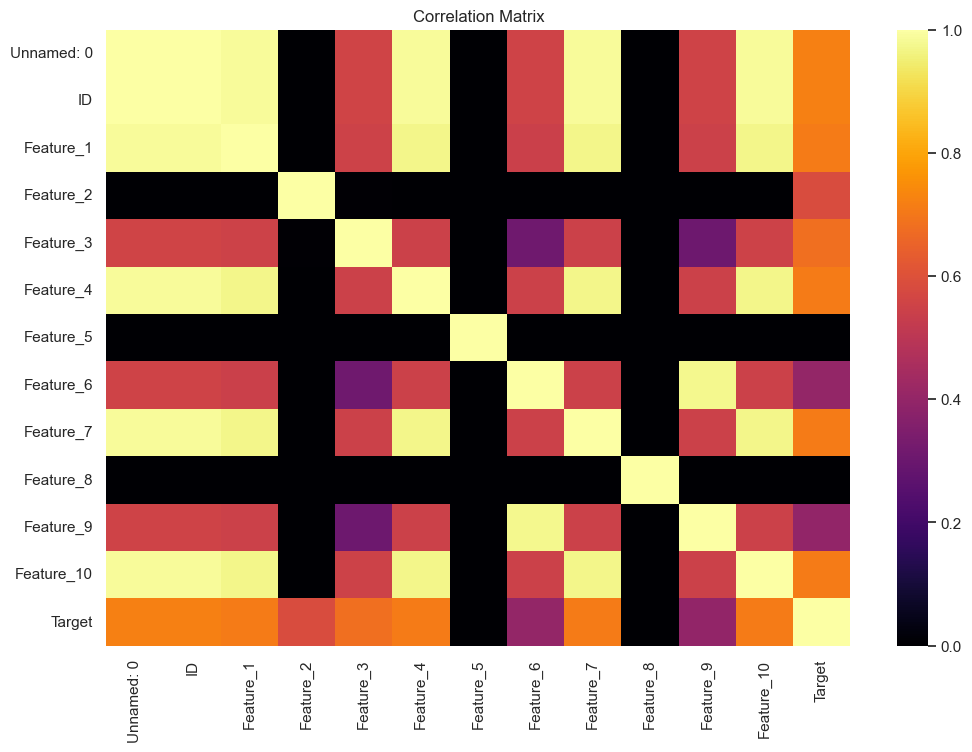

In [4]:
# Display correlation matrix
corr_matrix = df.corr().abs()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='inferno', vmin=0, vmax=1)
plt.title('Correlation Matrix')
plt.show()


# LSTM

In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm


In [6]:
# Check for any missing values
print(f"Missing values in dataset: {df.isna().sum().sum()}")

# Split into features and target
X = df.drop(columns=['Target'])
y = df['Target']

# Scale features
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# Scale target
y_mean = y.mean()
y_std = y.std()
print(f"Target statistics - Mean: {y_mean:.4f}, Std: {y_std:.4f}")
y_scaled = (y - y_mean) / y_std


Missing values in dataset: 0
Target statistics - Mean: 19.6674, Std: 15.5944


In [7]:
def create_sequences(X, y, seq_length):
    xs, ys = [], []
    for i in range(len(X) - seq_length):
        xs.append(X[i:i+seq_length])
        ys.append(y[i+seq_length])
    return np.array(xs), np.array(ys)

# Create sequences
seq_length = 10
X_seq, y_seq = create_sequences(X_scaled, y_scaled, seq_length)
print(f"Sequence shapes: X = {X_seq.shape}, y = {y_seq.shape}")

# Split into training and test sets
train_size = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:train_size], X_seq[train_size:]
y_train, y_test = y_seq[:train_size], y_seq[train_size:]

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)

print(f"Training data: X = {X_train_tensor.shape}, y = {y_train_tensor.shape}")
print(f"Test data: X = {X_test_tensor.shape}, y = {y_test_tensor.shape}")


Sequence shapes: X = (9980, 10, 12), y = (9980,)
Training data: X = torch.Size([7984, 10, 12]), y = torch.Size([7984, 1])
Test data: X = torch.Size([1996, 10, 12]), y = torch.Size([1996, 1])


In [8]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_size // 2, 1)
        
    def forward(self, x):
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        
        lstm_out, _ = self.lstm(x, (h0, c0))
        
        out = self.fc1(lstm_out[:, -1, :])
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        
        return out


In [9]:
# Model configuration
input_size = X_train.shape[2]
hidden_size = 128
num_layers = 2
dropout = 0.2

# Create model and training components
model = LSTMModel(input_size, hidden_size, num_layers, dropout)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=5)

# Create DataLoader
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)


In [10]:
# Training parameters
num_epochs = 200
patience = 15
best_loss = float('inf')
counter = 0
train_losses = []
val_losses = []

# Training loop with tqdm
for epoch in tqdm(range(num_epochs), desc='Training Progress', position=0):
    model.train()
    epoch_loss = 0
    
    # Add progress bar for batches
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', position=1, leave=False)
    for batch_X, batch_y in pbar:
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        # Update progress bar with current loss
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor)
        val_losses.append(val_loss.item())
        
        scheduler.step(val_loss)
        
        if val_loss < best_loss:
            best_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), 'best_lstm_model.pth')
        else:
            counter += 1
    
    if counter >= patience:
        print(f'\nEarly stopping triggered at epoch {epoch+1}')
        break
    
    if (epoch+1) % 10 == 0:
        print(f'\nEpoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss.item():.4f}')

# Load best model
model.load_state_dict(torch.load('best_lstm_model.pth'))



Training Progress:   0%|                                                                                     | 0/200 [00:00<?, ?it/s]


Epoch 1/200:   0%|                                                                                           | 0/125 [00:00<?, ?it/s]


Epoch 1/200:   0%|                                                                              | 0/125 [00:00<?, ?it/s, loss=0.8138]


Epoch 1/200:   0%|                                                                              | 0/125 [00:00<?, ?it/s, loss=0.9220]


Epoch 1/200:   0%|                                                                              | 0/125 [00:00<?, ?it/s, loss=1.0541]

...


Epoch 50/200:  96%|███████████████████████████████████████████████████████████████▎  | 120/125 [00:00<00:00, 141.14it/s, loss=0.0179]


Epoch 50/200:  96%|███████████████████████████████████████████████████████████████▎  | 120/125 [00:00<00:00, 141.14it/s, loss=0.0179]


Training Progress:  24%|██████████████████▌                                                         | 49/200 [00:46<02:23,  1.05it/s]


Early stopping triggered at epoch 50


<All keys matched successfully>

In [11]:
# Evaluate the model
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f'MSE: {mse:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'MAE: {mae:.4f}')
    print(f'R² Score: {r2:.4f}')


MSE: 0.0095
RMSE: 0.0973
MAE: 0.0725
R² Score: 0.9816


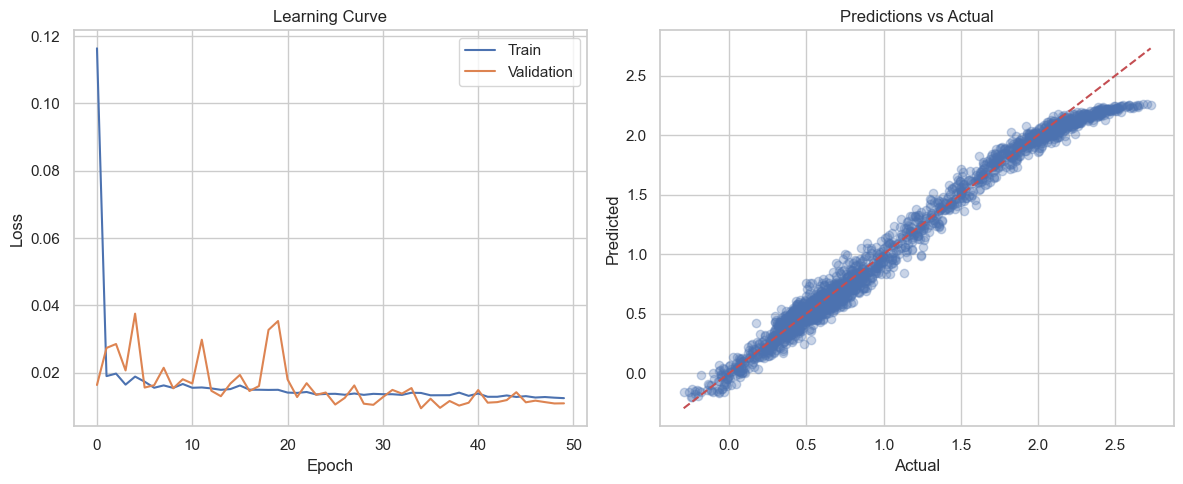

In [12]:
# Plot results
plt.figure(figsize=(12, 5))

# Plot learning curve
plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.plot(val_losses)
plt.title('Learning Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

# Plot predictions vs actual
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Predictions vs Actual')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.tight_layout()
plt.show()
